<h1 style="font-family:verdana;"> <center> </center> </h1>
<h1 style="font-family:verdana;"> <center>Basic Introduction To Machine Learning</center> </h1>
<h1 style="font-family:verdana;"> <center>AL-2002 Artifical Intelligence Spring 2026</center> </h1>
<p><center style="color:#159364; font-family:cursive; font-size:20px;">Instructor: Ms. Zill-E-Huma</center></p>

***

Name: Moiz Ansari

Reg No.: 23i-0523

Sec: F
***


# Exploratory Data Analysis and Pre-processing on Black Friday Sales
A retail company `“ABC Private Limited”` wants to understand the customer purchase behaviour (specifically, purchase amount) against various products of different categories. They have shared purchase summary of various customers for selected high volume products from last month.
The data set also contains customer demographics (age, gender, marital status, citytype, stayincurrentcity), product details (productid and product category) and Total purchaseamount from last month.

Now, they want to build a model to predict the purchase amount of customer against various products which will help them to create personalized offer for customers against different products.
## **Tasks to perform**
**`Purchase column`** is the **`Target Variable`**, perform Univariate Analysis and Bivariate Analysis w.r.t the Purchase.

Masked in the column description means already converted from categorical value to numerical column.


### **DATA PREPROCESSING**

* Check basic statistics of dataset e.g. mean, median, std, 1st quartile, 2nd quartile, and 3rd quartiles.
* Check for missing values (NaN and NULL values) in the data
* Check for unique values in data

### **Perform EDA**
* Purchase Distribution (find the correlation between the features, identifying which feautre contribute the most.)
* Check for outliers
* Analysis by Gender, Marital Status, occupation, occupation vs purchase , purchase by city, purchase by age group, etc
* Drop unnecessary fields
* Convert categorical data into integer using map function (e.g 'Gender' column), e.g.,
* missing value treatment.
* Rename columns
* fill nan values
* map range variables into integers (e.g 'Age' column)

### **Data Visualisation**
* visualize individul column
  * Age vs Purchased
  * Occupation vs Purchased
  * Product_category_1 vs Purchased
  * Product_category_2 vs Purchased
  * Product_category_3 vs Purchased
  * City category pie chart

check for more possible plots

# Importing Necessary Libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from statsmodels.tools import add_constant

# 📥 Load The Dataset

In [40]:
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/train.csv")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Display (Look into) the first 5 entries and last 5 entries of dataset.

In [41]:
display(df.head())
print()
display(df.tail())

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
550063,1006033,P00372445,M,51-55,13,B,1,1,20,NaN,NaN,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,NaN,NaN,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,NaN,NaN,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,NaN,NaN,365
550067,1006039,P00371644,F,46-50,0,B,4+,1,20,NaN,NaN,490


Find the dimensionality of dataset

In [42]:
print("Dimensionality of dataset (rows, columns):", df.shape)

Dimensionality of dataset (rows, columns): (550068, 12)


Show the summary of dataset.

Statistical summary of numerical variables

In [43]:
print("======================== Dataset Summary ========================")
df.info()

print("\n======================== Statistical Summary ========================")
display(df.describe())

======================== Dataset Summary ========================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: flo

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


Identify the null Value and NAN values (missing values) from the dataset, and remove it or fill it decide it based upon your conclusion.

In [44]:
print("No. of missing values BEFORE cleaning:\n", df.isnull().sum())

df.fillna(0, inplace=True)

print("\nNo. of missing values AFTER cleaning:\n", df.isnull().sum())

No. of missing values BEFORE cleaning:
 User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

No. of missing values AFTER cleaning:
 User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64


Check the duplicate values

In [45]:
print("No. of duplicate rows: ", df.duplicated().sum())

df.drop_duplicates(inplace=True)

No. of duplicate rows:  0


Count the Purchase distribution. If data is imbalanced, your model may become biased. So resolve it if data is biased.

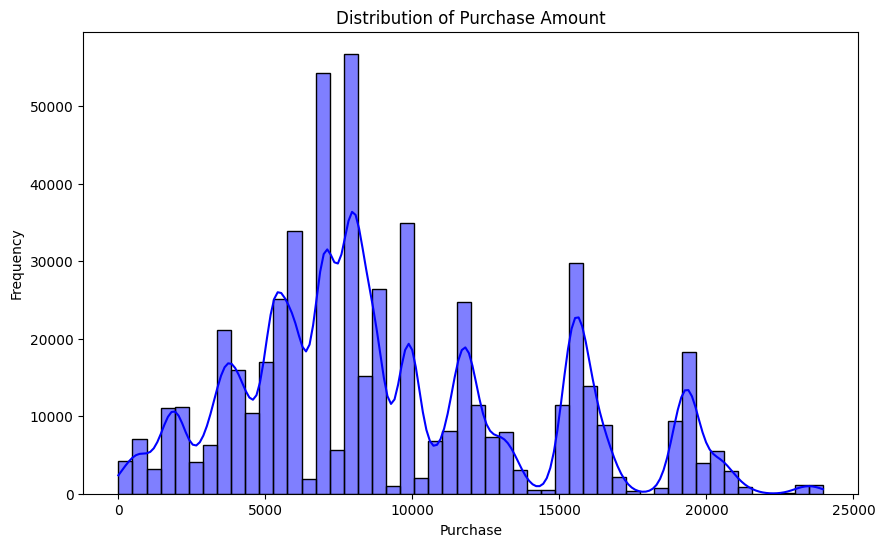

In [46]:
plt.figure(figsize=(10,6))
sns.histplot(df['Purchase'], bins=50, kde=True, color='blue')
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase')
plt.ylabel('Frequency')
plt.show()

Check for unique values in data `(target variable)`

In [47]:
print("No. of unique purchase values: ", df['Purchase'].nunique())

No. of unique purchase values:  18105


Convert categorical data into integer using map function (e.g 'Gender' column)

In [48]:
df['Gender'] = df['Gender'].map({'F': 0, 'M': 1})
df['City_Category'] = df['City_Category'].map({'A': 0, 'B': 1, 'C': 2})
df['Age'] = df['Age'].map({'0-17': 0, '18-25': 1, '26-35': 2, '36-45': 3, '46-50': 4, '51-55': 5, '55+': 6})

# Output first five rows
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,0,0,10,0,2,0,3,0.0,0.0,8370
1,1000001,P00248942,0,0,10,0,2,0,1,6.0,14.0,15200
2,1000001,P00087842,0,0,10,0,2,0,12,0.0,0.0,1422
3,1000001,P00085442,0,0,10,0,2,0,12,14.0,0.0,1057
4,1000002,P00285442,1,6,16,2,4+,0,8,0.0,0.0,7969


### Data Visualisation

Graph (histogram, scatter plot, bar blot, box plot, heatmap)

Example code for heatmap:


    cols = ["col1", "col2", "col3", "col4", "col5"]

    plt.figure(figsize=(10,6))
    sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap (Selected Features)")
    plt.show()

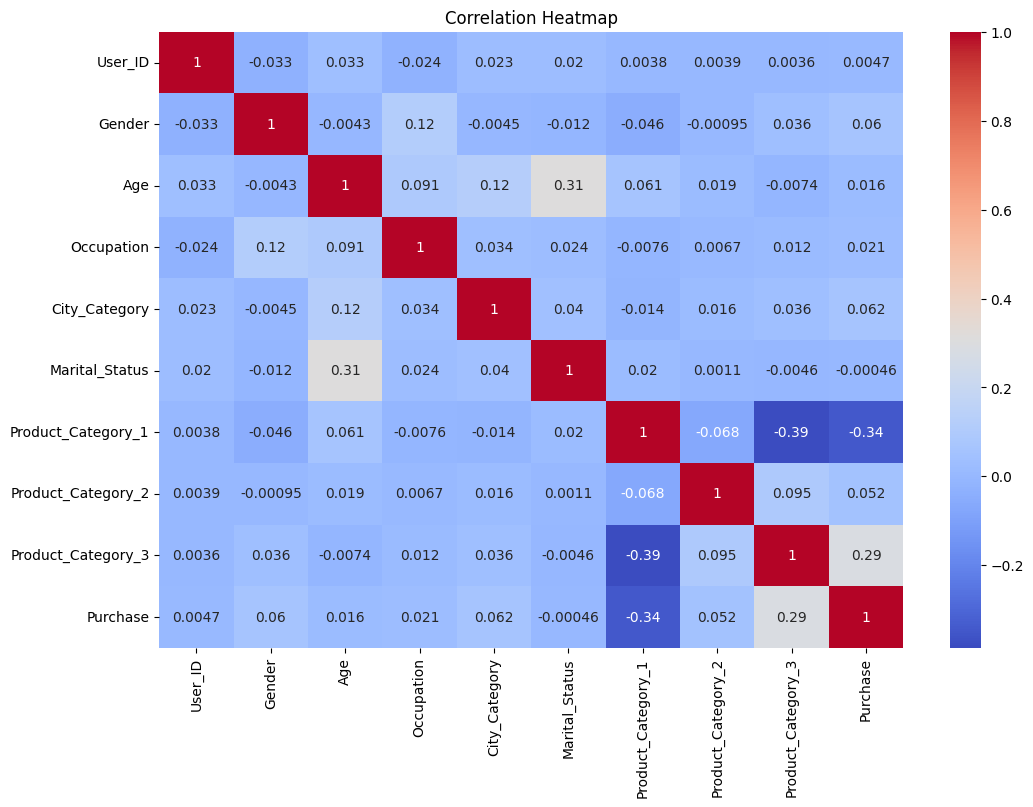

In [49]:
numeric_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Plot the Pie chart for purchase distribution with features.

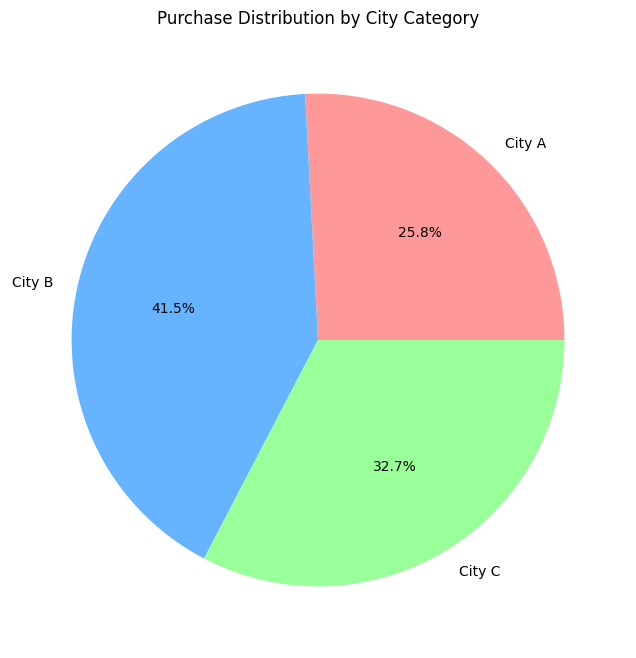

In [57]:
city_purchase = df.groupby('City_Category')['Purchase'].sum()

plt.figure(figsize=(8, 8))
plt.pie(city_purchase, labels=['City A', 'City B', 'City C'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Purchase Distribution by City Category')
plt.show()

Declare feature vector and target variable

In [52]:
# Target variable
y = df['Purchase']

# Feature vector
X = df.drop(['Purchase', 'User_ID', 'Product_ID'], axis=1)

X = pd.get_dummies(X, drop_first=True)

Normalize the features through feature scaling

In [53]:
scaler = MinMaxScaler()
X_scalled_arr = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scalled_arr, columns=X.columns)

If the data is biased then add the biasness.

In [56]:
X_const = add_constant(X_scaled)

***

                              That's all for today's class, hope you like the class:)